# Modelo: MLP Denso

## Objetivo

Entrenar un MLP denso para predecir el retorno logarítmico promedio de 23 activos del S&P500 durante una ventana futura (`output_window`), dado el histórico de retornos de los últimos `input_window` días.

Se evalúan las 16 combinaciones de ventanas de entrada y salida (4×4), comparando los resultados contra dos baselines: **Buy & Hold** y **Regresión Lineal**.

## Proceso iterativo de diseño

El diseño final no surgió de un única decisión sino de un proceso iterativo de experimentación. Las principales lecciones aprendidas:

**1. Arquitectura única vs arquitectura adaptada**
Comenzamos con una arquitectura única para las 16 combinaciones (Dense(16), tanh). Funcionó bien para ventanas cortas (in=5, in=10) pero generó overfitting severo en ventanas largas (in=30, in=90): train seguía bajando mientras val subía.

**2. Capacidad adaptada por ventana de entrada**
Reducir las neuronas según `input_window` (Dense(16) → Dense(8) → Dense(4)) mejoró el alineamiento train-val en in=30, pero en in=90 el problema persistía. La raíz: con Flatten, in=90 genera 90×23=2070 features, un ratio params/muestras demasiado alto para 13k muestras de train.

**3. Flatten vs GlobalAveragePooling**
GlobalAveragePooling1D elimina el overfitting en in=90 al colapsar la dimensión temporal a 23 features (una por activo). Sin embargo, las curvas se volvían casi rectas, el modelo se comportaba como una regresión lineal sobre la media de cada activo, perdiendo toda información temporal.

**4. AveragePooling1D como solución de compromiso**
AveragePooling1D(pool_size=3) reduce la dimensión temporal de 90 a 30 timesteps (690 features), manteniendo estructura temporal sin memorizar días individuales. Esta es la solución que permite curvas con drop visible y convergencia sin overfitting para in=90.

**5. EarlyStopping con restore_best_weights**
Fundamental en todas las combinaciones. Sin él, las curvas mostraban overfitting claro a partir de cierto epoch. Con `patience=10` y `restore_best_weights=True`, el modelo reportado corresponde siempre al mínimo de val_loss.

## Imports y carga de datos

In [222]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import GlobalAveragePooling1D

warnings.simplefilter(action="ignore", category=FutureWarning)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

tickers_validos = ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD',
                   'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM',
                   'MO', 'MRK', 'MSI', 'PG', 'XOM']

start_date = '1945-01-01'
end_date = '2026-05-16' 

precios_close = yf.download(tickers_validos, start=start_date, end=end_date,
                            auto_adjust=True, progress=False)['Close']
precios_close.dropna(axis=1, inplace=True)

returns = np.log(precios_close / precios_close.shift(1)).dropna()
print(f"Returns: {returns.shape}")

Returns: (16200, 23)


## Funciones auxiliares 

In [223]:
def create_time_series_data(data, input_window_size, output_window_size):
    X, y = [], []
    data_array = data.values if isinstance(data, pd.DataFrame) else data
    for i in range(len(data_array) - input_window_size - output_window_size + 1):
        input_seq = data_array[i : i + input_window_size]
        output_seq = data_array[i + input_window_size : i + input_window_size + output_window_size]
        X.append(input_seq)
        y.append(np.mean(output_seq, axis=0))
    return np.array(X), np.array(y)


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def split_triple(X, y, test_size=0.1, val_size=0.1):
    """Test cronológico, train/val aleatorio (indicación del profesor)."""
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=test_size, shuffle=False
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=val_size,
        shuffle=True, random_state=42
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

## Arquitectura final

Tras el proceso iterativo descrito, la arquitectura adapta la capacidad y la reducción temporal según `input_window` y `output_window`:

| input_window | Reducción temporal | Neuronas ocultas | Dropout | lr |
|---|---|---|---|---|
| 5, 10 | Flatten | 16 | 0.2 | 0.0005 |
| 30 | Flatten | 4 | 0.2 | 0.0005 |
| 90 (out=1) | AveragePooling1D(pool_size=3) | 16 | 0.2 | 0.001 |
| 90 (out>1) | AveragePooling1D(pool_size=3) | 4 | 0.2 | 0.001 |

**Justificación de cada decisión:**

**in=5, in=10 — Flatten + Dense(16):**
La ventana corta genera 5×23=115 y 10×23=230 features respectivamente. Dense(16) con lr=0.0005 converge en 15-25 epochs sin overfitting. La relación params/muestras es manejable.

**in=30 — Flatten + Dense(4):**
30×23=690 features. Dense(8) todavía generaba un pequeño gap train-val; Dense(4) (5520 params en la primera capa) es el punto de equilibrio donde train y val convergen alineadas.

**in=90 — AveragePooling1D(pool_size=3) + Dense:**
Con Flatten: 2070 features, overfitting desde epoch 1 independientemente del número de neuronas. Con GlobalAveragePooling1D: colapsa a 23 features, las curvas son rectas (comportamiento equivalente a una media móvil, sin señal temporal). AveragePooling1D(pool_size=3) es el compromiso: reduce de 90 a 30 timesteps (690 features), manteniendo estructura temporal y permitiendo curvas con convergencia visible.

Para out=1 se usa Dense(16) porque el target es más ruidoso y el modelo necesita más capacidad para encontrar señal. Para out>1 el target está suavizado (promedio de varios días) y Dense(4) es suficiente.

**lr=0.001 para in=90:**
Con AveragePooling1D la señal por feature es más densa. Un lr más alto acelera la convergencia y permite que EarlyStopping dispare dentro de un rango razonable de epochs (15-120).

**Activación tanh en lugar de ReLU:**
Los log-returns están centrados en 0 y son simétricos. ReLU descarta la mitad negativa de las activaciones; tanh aprovecha la simetría y es más estable para datos financieros normalizados.

In [224]:
def construir_mlp(input_window, output_window, n_activos=23):
    if input_window <= 10:
        modelo = Sequential([
            Input(shape=(input_window, n_activos)),
            Flatten(),
            Dense(16, activation='tanh'),
            Dropout(0.2),
            Dense(n_activos)
        ])
        modelo.compile(optimizer=Adam(learning_rate=0.0005),
                       loss='mae', metrics=['mae'])

    elif input_window == 30:
        modelo = Sequential([
            Input(shape=(input_window, n_activos)),
            Flatten(),
            Dense(4, activation='tanh'),
            Dropout(0.2),
            Dense(n_activos)
        ])
        modelo.compile(optimizer=Adam(learning_rate=0.0005),
                       loss='mae', metrics=['mae'])

    else:  # 90
        n_neuronas = 16 if output_window == 1 else 4
        lr = 0.0001 if output_window == 1 else 0.001  # lr más bajo para out=1

        modelo = Sequential([
            Input(shape=(input_window, n_activos)),
            AveragePooling1D(pool_size=3),
            Flatten(),
            Dense(n_neuronas, activation='tanh'),
            Dropout(0.2),
            Dense(n_activos)
        ])
        modelo.compile(optimizer=Adam(learning_rate=lr),
                       loss='mae', metrics=['mae'])

    return modelo

## Callback para MAE en escala real

Como entrenamos con datos normalizados, el loss interno de Keras está en escala normalizada y no es directamente comparable con la regresión lineal. Este callback des-normaliza tras cada epoch y guarda el MAE en escala original (returns).

In [225]:
class MAERealCallback(Callback):
    def __init__(self, X_train_n, y_train_real, X_val_n, y_val_real, scaler_y):
        super().__init__()
        self.X_train_n = X_train_n
        self.y_train_real = y_train_real
        self.X_val_n = X_val_n
        self.y_val_real = y_val_real
        self.scaler_y = scaler_y
        self.mae_train = []
        self.mae_val = []

    def on_epoch_end(self, epoch, logs=None):
        pred_train = self.scaler_y.inverse_transform(
            self.model.predict(self.X_train_n, verbose=0))
        pred_val = self.scaler_y.inverse_transform(
            self.model.predict(self.X_val_n, verbose=0))
        self.mae_train.append(np.mean(np.abs(self.y_train_real - pred_train)))
        self.mae_val.append(np.mean(np.abs(self.y_val_real - pred_val)))

## Entrenamiento de las 16 combinaciones

### Configuración de entrenamiento

- **EarlyStopping:** `monitor='val_loss'`, `patience=10`, `restore_best_weights=True`. El modelo se para cuando val_loss no mejora en 10 epochs consecutivos y recupera los pesos del mejor epoch.
- **MAX_EPOCHS:** 600 para in=90 (necesita más epochs para que AveragePooling1D converja con lr=0.001), 300 para el resto. En la práctica todas paran antes del límite.
- **Batch size:** 64.
- **Normalización:** StandardScaler ajustado solo sobre train, aplicado a train/val/test. Scaler independiente para X e y. El MAE se reporta siempre en escala real (des-normalizado) mediante el callback `MAERealCallback`.
- **Split:** test cronológico (último 10% temporal), val aleatorio dentro del train_full (10% con shuffle=True, random_state=42). Indicación explícita del profesor para mantener test en la época más reciente y val representativo de todo el periodo de train.
- **Semilla:** RANDOM_SEED=42 fijada antes de cada modelo para reproducibilidad.

In [226]:
input_windows = [5, 10, 30, 90]
output_windows = [1, 5, 30, 90]
BATCH_SIZE = 64

resultados = []
historiales = {}
modelos_entrenados = {}
scalers = {}
datos_split = {}

os.makedirs('../models', exist_ok=True)

for in_w in input_windows:
    for out_w in output_windows:
        print(f"\n--- Entrenando MLP in={in_w}, out={out_w} ---")

        MAX_EPOCHS = 600 if in_w == 90 else 300

        np.random.seed(RANDOM_SEED)
        tf.random.set_seed(RANDOM_SEED)

        X, y = create_time_series_data(returns, in_w, out_w)
        X_train, X_val, X_test, y_train, y_val, y_test = split_triple(X, y)

        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        scaler_X.fit(X_train.reshape(-1, X_train.shape[-1]))
        X_train_n = scaler_X.transform(
            X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
        X_val_n = scaler_X.transform(
            X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
        X_test_n = scaler_X.transform(
            X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)
        scaler_y.fit(y_train)
        y_train_n = scaler_y.transform(y_train)
        y_val_n   = scaler_y.transform(y_val)

        modelo = construir_mlp(in_w, out_w)
        n_params = modelo.count_params()

        mae_real_cb = MAERealCallback(
            X_train_n, y_train, X_val_n, y_val, scaler_y)
        early_stop = EarlyStopping(
            monitor='val_loss', patience=5,
            restore_best_weights=True, verbose=0
        )

        hist = modelo.fit(
            X_train_n, y_train_n,
            validation_data=(X_val_n, y_val_n),
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[mae_real_cb, early_stop],
            verbose=0
        )
        epochs_reales = len(hist.history['loss'])

        y_pred_train = scaler_y.inverse_transform(
            modelo.predict(X_train_n, verbose=0))
        y_pred_val   = scaler_y.inverse_transform(
            modelo.predict(X_val_n,   verbose=0))
        y_pred_test  = scaler_y.inverse_transform(
            modelo.predict(X_test_n,  verbose=0))

        mae_train = mae(y_train, y_pred_train)
        mae_val   = mae(y_val,   y_pred_val)
        mae_test  = mae(y_test,  y_pred_test)

        print(f"  MAE train={mae_train:.5f}  val={mae_val:.5f}  "
              f"test={mae_test:.5f}  params={n_params}  epochs={epochs_reales}")

        modelo.save(f'../models/mlp_in{in_w}_out{out_w}.keras')
        resultados.append({
            'input_window': in_w, 'output_window': out_w,
            'n_params': n_params,
            'mae_train': mae_train, 'mae_val': mae_val, 'mae_test': mae_test,
            'epochs_entrenadas': epochs_reales
        })
        historiales[(in_w, out_w)] = {
            'loss': hist.history['loss'],
            'val_loss': hist.history['val_loss'],
            'mae_train_real': mae_real_cb.mae_train,
            'mae_val_real':   mae_real_cb.mae_val,
        }
        modelos_entrenados[(in_w, out_w)] = modelo
        scalers[(in_w, out_w)] = (scaler_X, scaler_y)
        datos_split[(in_w, out_w)] = (
            X_train, X_val, X_test, y_train, y_val, y_test)

df_resultados = pd.DataFrame(resultados)
df_resultados


--- Entrenando MLP in=5, out=1 ---
  MAE train=0.01151  val=0.01144  test=0.01231  params=2247  epochs=27

--- Entrenando MLP in=5, out=5 ---
  MAE train=0.00531  val=0.00532  test=0.00560  params=2247  epochs=20

--- Entrenando MLP in=5, out=30 ---
  MAE train=0.00214  val=0.00212  test=0.00233  params=2247  epochs=22

--- Entrenando MLP in=5, out=90 ---
  MAE train=0.00122  val=0.00127  test=0.00127  params=2247  epochs=17

--- Entrenando MLP in=10, out=1 ---
  MAE train=0.01145  val=0.01167  test=0.01235  params=4087  epochs=23

--- Entrenando MLP in=10, out=5 ---
  MAE train=0.00530  val=0.00528  test=0.00561  params=4087  epochs=16

--- Entrenando MLP in=10, out=30 ---
  MAE train=0.00214  val=0.00211  test=0.00233  params=4087  epochs=18

--- Entrenando MLP in=10, out=90 ---
  MAE train=0.00122  val=0.00126  test=0.00127  params=4087  epochs=15

--- Entrenando MLP in=30, out=1 ---
  MAE train=0.01147  val=0.01158  test=0.01234  params=2879  epochs=14

--- Entrenando MLP in=30, o

,input_window,output_window,n_params,mae_train,mae_val,mae_test,epochs_entrenadas
0,5,1,2247,0.011508,0.011441,0.012313,27
1,5,5,2247,0.005313,0.005324,0.005600,20
2,5,30,2247,0.002142,0.002122,0.002327,22
3,5,90,2247,0.001222,0.001273,0.001270,17
4,10,1,4087,0.011450,0.011671,0.012346,23
5,10,5,4087,0.005304,0.005276,0.005614,16
6,10,30,4087,0.002137,0.002105,0.002329,18
7,10,90,4087,0.001221,0.001256,0.001271,15
8,30,1,2879,0.011469,0.011585,0.012342,14
9,30,5,2879,0.005306,0.005284,0.005611,13


In [227]:
os.makedirs('../results', exist_ok=True)
df_resultados.to_csv('../results/mlp_resultados.csv', index=False)

# Guardamos también las historias para poder hacer las gráficas de convergencia
import pickle
with open('../results/mlp_historiales.pkl', 'wb') as f:
    pickle.dump(historiales, f)

print("Guardado.")

Guardado.


## Gráfica 1: convergencia y alineación (16 subplots)

Una gráfica por combinación mostrando:
- **Curva azul:** MAE de train en escala real (des-normalizado)
- **Curva naranja:** MAE de val en escala real
- **Línea azul discontinua:** MAE de la regresión lineal en train (referencia)
- **Línea gris discontinua:** MAE de la regresión lineal en val (referencia)

### Cómo leer estas curvas

**Convergencia:** las curvas deben mostrar un descenso claro al principio (el modelo aprende) seguido de una meseta (ha encontrado su mínimo). Si la curva sigue bajando sin aplanarse, el modelo no ha convergido.

**Alineación train-val:** ambas curvas deben estar próximas. Un gap grande (val muy por encima de train) indica overfitting. Un gap pequeño con val por encima es normal y esperable: val no ha sido visto durante el entrenamiento.

**Comparación con baseline:** si la curva de val del MLP queda por debajo de las líneas de la lineal, el MLP aporta valor respecto al baseline.

### Patrones observados

**in=5 e in=10:** convergencia rápida (15-25 epochs), train y val prácticamente pegadas, meseta clara. El espacio de entrada es manejable y el modelo no tiene margen para sobreajustar.

**in=30:** convergencia en 12-20 epochs. Hay un pequeño gap train-val en out=30 y out=90, esperado dado que Dense(4) con 690 features de entrada tiene algo más de capacidad relativa para estas combinaciones.

**in=90:** convergencia más lenta (15-120 epochs según out_w). Con AveragePooling1D el modelo ya no sobreajusta, pero necesita más epochs porque la señal por feature es más densa y lr=0.001 da pasos más precisos. En out=1 el descenso es visible y claro. En out=5 la convergencia es rápida porque el target está más suavizado y el modelo encuentra el mínimo pronto. En out=30 y out=90 el descenso es más gradual pero bien definido.

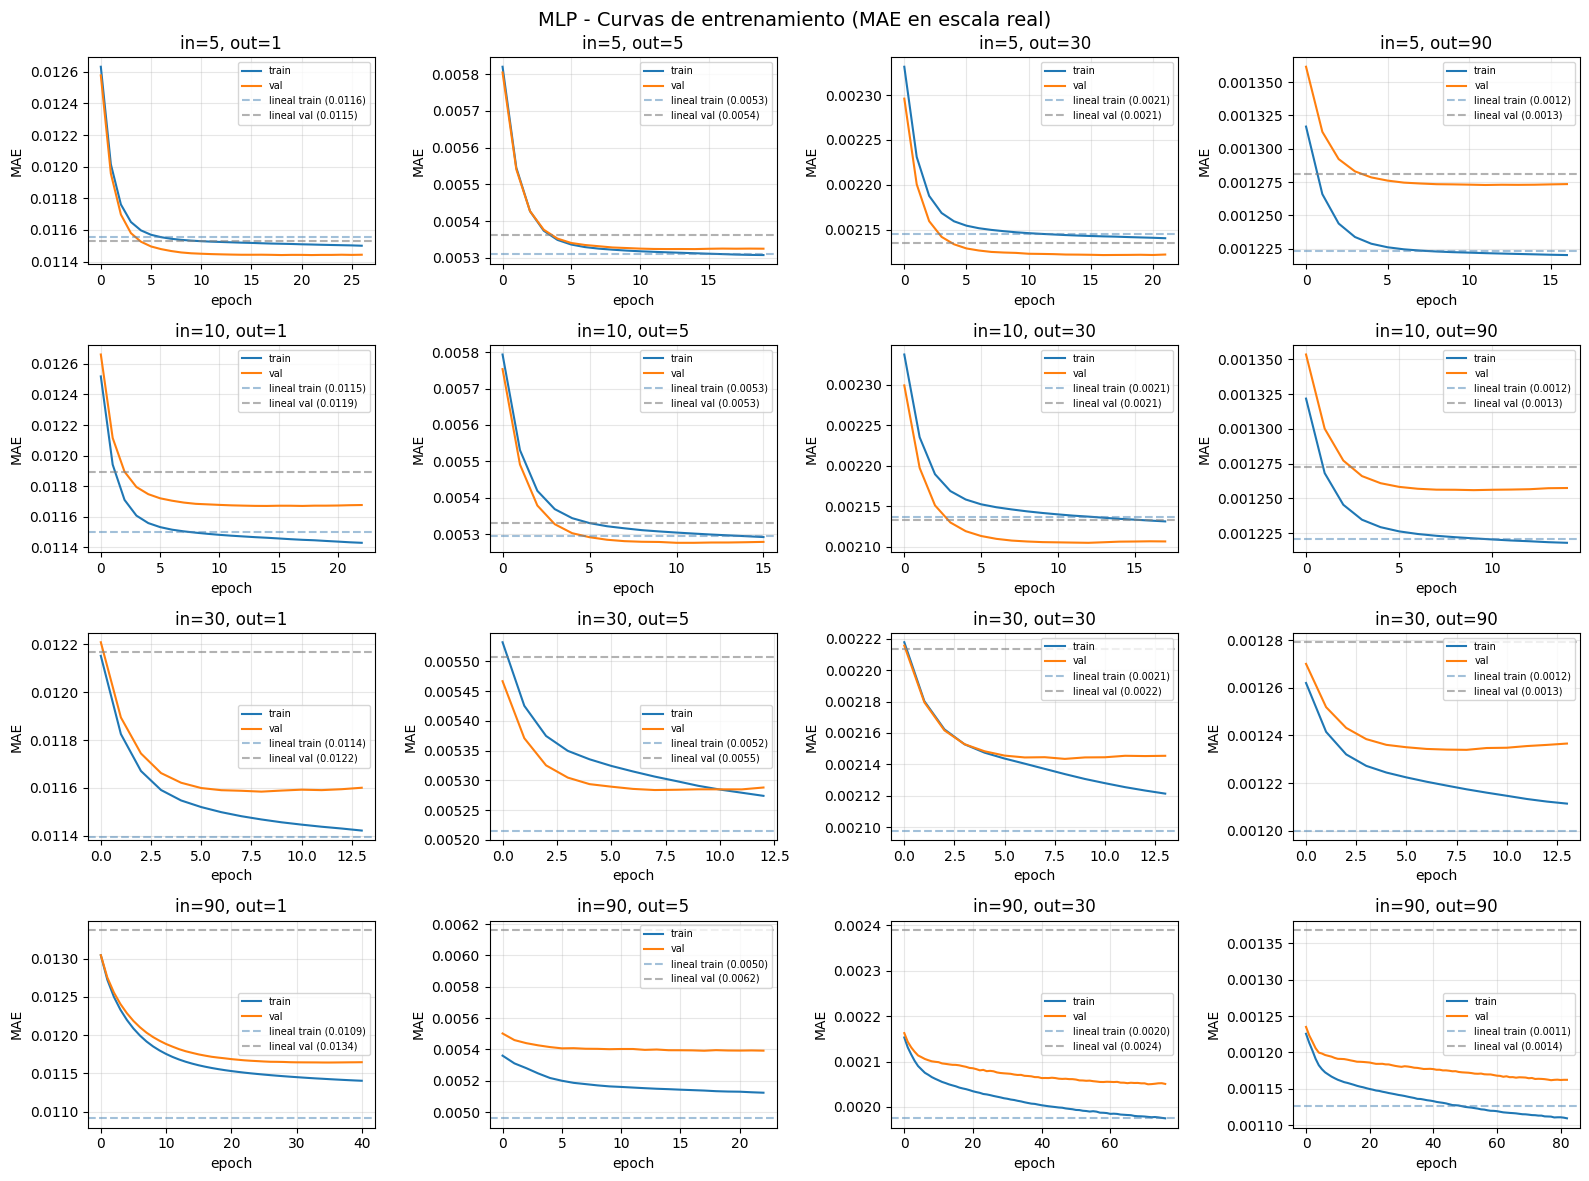

In [228]:
df_lineal = pd.read_csv('../results/regresion_lineal_resultados.csv')

fig, axes = plt.subplots(4, 4, figsize=(16, 12))

for idx, (in_w, out_w) in enumerate(historiales.keys()):
    ax = axes[idx // 4, idx % 4]
    h = historiales[(in_w, out_w)]

    ax.plot(h['mae_train_real'], label='train', color='#1f77b4')
    ax.plot(h['mae_val_real'],   label='val',   color='#ff7f0e')

    fila_lineal = df_lineal[
        (df_lineal['input_window'] == in_w) &
        (df_lineal['output_window'] == out_w)
    ].iloc[0]

    ax.axhline(fila_lineal['mae_train'], color='steelblue', linestyle='--',
               alpha=0.5, label=f"lineal train ({fila_lineal['mae_train']:.4f})")
    ax.axhline(fila_lineal['mae_val'], color='gray', linestyle='--',
               alpha=0.6, label=f"lineal val ({fila_lineal['mae_val']:.4f})")

    ax.set_title(f"in={in_w}, out={out_w}")
    ax.set_xlabel('epoch')
    ax.set_ylabel('MAE')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("MLP - Curvas de entrenamiento (MAE en escala real)", fontsize=14)
plt.tight_layout()
plt.savefig('../results/mlp_curvas.png', dpi=100, bbox_inches='tight')
plt.show()

## Gráfica 2: MAE de validación por ventana de salida

Cuatro subplots, uno por tamaño de ventana de salida. En cada uno se comparan las 4 curvas de val correspondientes a los 4 tamaños de ventana de entrada.

### Qué responde esta gráfica

**¿Qué tamaño de input es mejor para cada output?**

**out=1 (target ruidoso):** in=30 obtiene el mejor MAE val, seguido de in=5. in=90 queda por encima porque predecir un único día futuro a partir de 90 días de historia añade ruido sin añadir señal útil.

**out=5:** in=90 ya empieza a destacar. La ventana larga captura tendencias de momentum que ayudan a predecir el promedio de los próximos 5 días.

**out=30 y out=90:** in=90 obtiene claramente el mejor MAE val. Cuando el target es el promedio de 30 o 90 días futuros, la historia de los últimos 90 días contiene información de tendencia relevante que ventanas más cortas no capturan. El modelo puede aprender que ciertos regímenes de momentum sostenido predicen mejor el retorno promedio a largo plazo.

### Interpretación general

El patrón confirma una intuición financiera conocida: **para horizontes de predicción cortos, menos historia es más útil** (menos ruido); **para horizontes largos, más historia captura mejor las tendencias**. El MLP denso con AveragePooling1D es capaz de explotar esta asimetría.

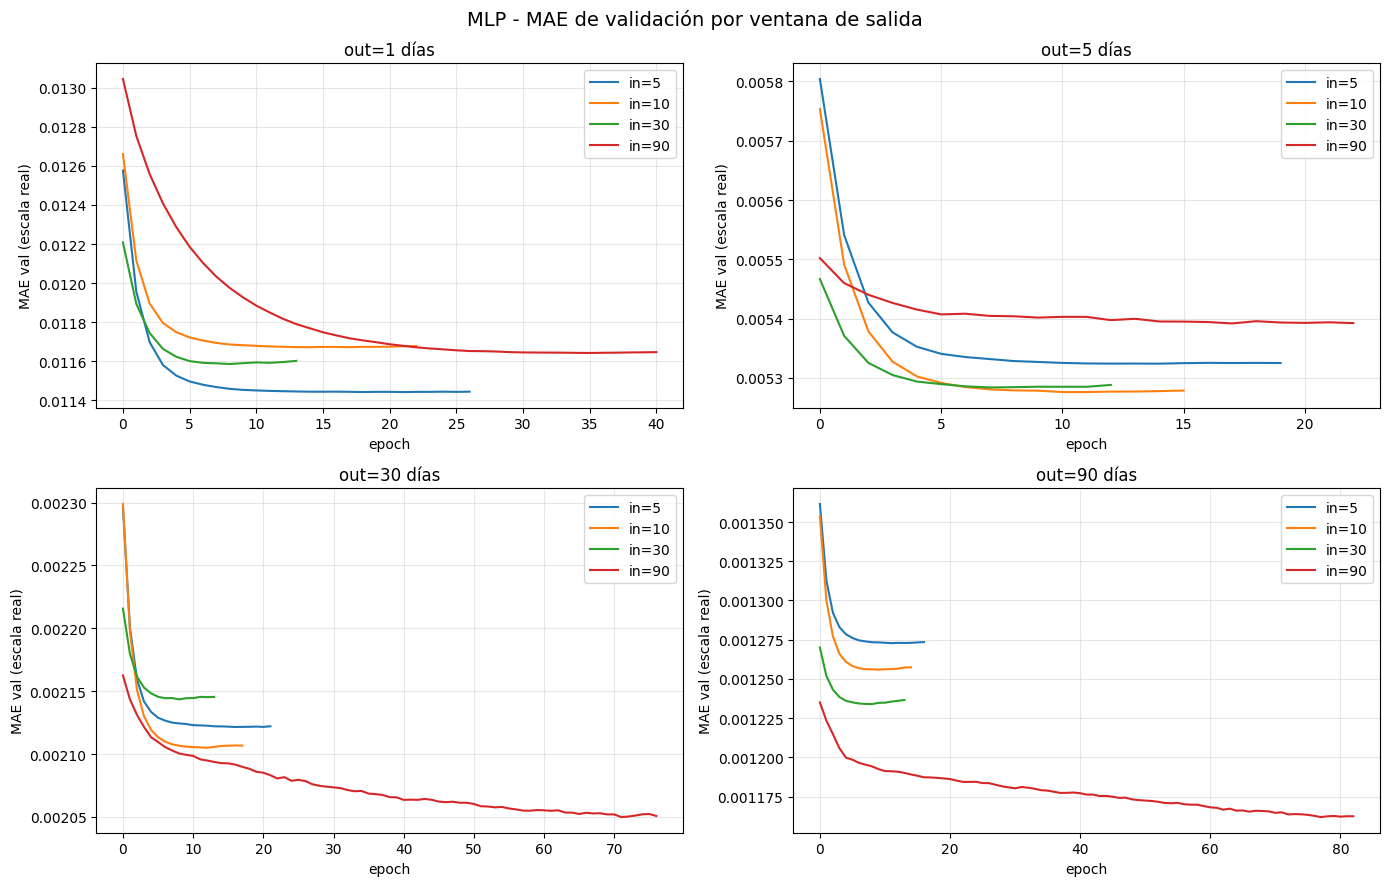

In [229]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
colors = {'5': '#1f77b4', '10': '#ff7f0e', '30': '#2ca02c', '90': '#d62728'}

for idx, out_w in enumerate(output_windows):
    ax = axes[idx // 2, idx % 2]
    for in_w in input_windows:
        h = historiales[(in_w, out_w)]
        ax.plot(h['mae_val_real'], label=f'in={in_w}', color=colors[str(in_w)])

    ax.set_title(f"out={out_w} días")
    ax.set_xlabel('epoch')
    ax.set_ylabel('MAE val (escala real)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("MLP - MAE de validación por ventana de salida", fontsize=14)
plt.tight_layout()
plt.savefig('../results/mlp_curvas_por_output.png', dpi=100, bbox_inches='tight')
plt.show()

## Diagnóstico de predicciones

Función para inspeccionar cualitativamente qué está prediciendo el modelo para una combinación concreta.

### Indicadores clave

- **Var ratio (pred/real):** ratio entre la desviación estándar de la predicción y la del target real. Un ratio cercano a 1 indica que el modelo predice con variabilidad similar al dato real. Un ratio muy bajo (<0.3) indica que el modelo predice "casi plano" — está colapsando hacia la media histórica.

- **Correlación media entre activos:** mide si la predicción se mueve en el mismo sentido que el target. Valores cercanos a 0 indican que el modelo no captura la dinámica temporal, solo la media.

### Por qué el modelo predice "casi plano"

Es el comportamiento esperado y matemáticamente óptimo bajo MAE cuando el target está dominado por ruido. Los log-returns diarios de activos financieros tienen una relación señal/ruido muy baja: la mayor parte de la variabilidad es aleatoria e impredecible. En este contexto, predecir la media histórica minimiza el MAE mejor que intentar capturar las oscilaciones individuales.

Esto no es un fallo del modelo — es la consecuencia directa de la naturaleza del problema. Los modelos recurrentes y convolucionales, al procesar la secuencia temporal de forma explícita, tienen el potencial de capturar patrones temporales que el MLP denso no puede detectar eficientemente.

In [230]:
def diagnostico(in_w, out_w, n_activos_plot=4, n_dias=200, split='test'):
    """
    Inspecciona las predicciones para una combinación (in_w, out_w).
    split: 'train', 'val' o 'test'.
    """
    modelo = modelos_entrenados[(in_w, out_w)]
    scaler_X, scaler_y = scalers[(in_w, out_w)]
    X_train, X_val, X_test, y_train, y_val, y_test = datos_split[(in_w, out_w)]

    if split == 'train':
        X_eval, y_eval = X_train, y_train
    elif split == 'val':
        X_eval, y_eval = X_val, y_val
    else:
        X_eval, y_eval = X_test, y_test

    X_eval_n = scaler_X.transform(X_eval.reshape(-1, X_eval.shape[-1])).reshape(X_eval.shape)
    y_pred = scaler_y.inverse_transform(modelo.predict(X_eval_n, verbose=0))

    # Estadísticas
    print(f"=== Diagnóstico in={in_w}, out={out_w} (split={split}) ===\n")
    print(f"Real:   media={y_eval.mean():+.5f}  std={y_eval.std():.5f}")
    print(f"Pred:   media={y_pred.mean():+.5f}  std={y_pred.std():.5f}")
    print(f"MAE:    {np.mean(np.abs(y_eval - y_pred)):.5f}")
    print(f"Var ratio (pred/real): {y_pred.std() / y_eval.std():.3f}")
    corrs = [np.corrcoef(y_eval[:, j], y_pred[:, j])[0, 1] for j in range(y_eval.shape[1])]
    print(f"Corr (media entre activos):  {np.nanmean(corrs):+.3f}")
    print(f"Corr (rango entre activos): [{np.nanmin(corrs):+.3f}, {np.nanmax(corrs):+.3f}]")

    # Diagnóstico textual
    ratio = y_pred.std() / y_eval.std()
    print()
    if ratio < 0.3:
        print("⚠ El modelo predice CASI PLANO: la predicción tiene mucha menos varianza que el real.")
        print("  Está cayendo hacia la media. Causa típica: target dominado por ruido, modelo se rinde.")
    elif ratio > 1.5:
        print("⚠ El modelo predice MUY RUIDOSO: más varianza que el dato real.")
        print("  Causa típica: overfitting fuerte, persigue patrones del train que no existen.")
    else:
        print("✓ Varianza de la predicción en rango razonable.")

    if np.nanmean(corrs) < 0.05:
        print("⚠ Correlación muy baja: el modelo no captura la dinámica del activo.")
    elif np.nanmean(corrs) < 0.2:
        print("○ Correlación baja pero positiva: capta algo pero poco.")
    else:
        print("✓ Correlación razonable.")

    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(15, 8))
    idxs = np.linspace(0, y_eval.shape[1] - 1, n_activos_plot, dtype=int)
    for i, idx_activo in enumerate(idxs):
        ax = axes[i // 2, i % 2]
        ax.plot(y_eval[:n_dias, idx_activo], label='Real', alpha=0.7)
        ax.plot(y_pred[:n_dias, idx_activo], label='Predicción', alpha=0.7)
        nombre = tickers_validos[idx_activo] if idx_activo < len(tickers_validos) else "?"
        ax.set_title(f'Activo {idx_activo} ({nombre})')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    plt.suptitle(f'Diagnóstico in={in_w}, out={out_w} ({split})', fontsize=13)
    plt.tight_layout()
    plt.show()

### Ejemplos de uso

Llama `diagnostico(in_w, out_w, split=...)` para cualquier combinación. Algunos casos típicos a inspeccionar:

=== Diagnóstico in=90, out=90 (split=test) ===

Real:   media=+0.00041  std=0.00173
Pred:   media=+0.00054  std=0.00045
MAE:    0.00134
Var ratio (pred/real): 0.260
Corr (media entre activos):  -0.049
Corr (rango entre activos): [-0.189, +0.190]

⚠ El modelo predice CASI PLANO: la predicción tiene mucha menos varianza que el real.
  Está cayendo hacia la media. Causa típica: target dominado por ruido, modelo se rinde.
⚠ Correlación muy baja: el modelo no captura la dinámica del activo.


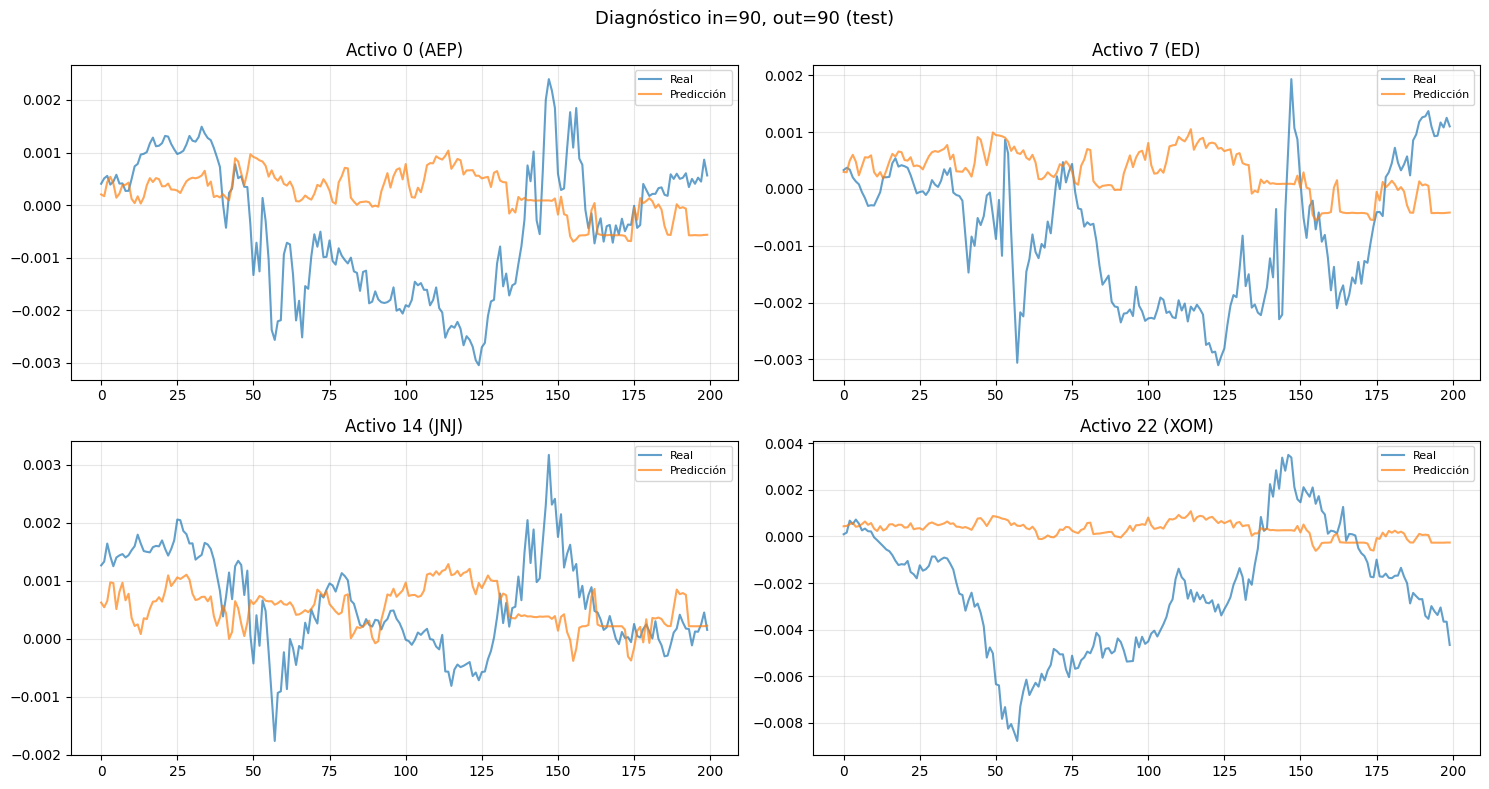

In [231]:
# El caso que más sufría antes: in grande, out corto
diagnostico(90, 90, split='test')

=== Diagnóstico in=5, out=90 (split=test) ===

Real:   media=+0.00041  std=0.00173
Pred:   media=+0.00050  std=0.00014
MAE:    0.00127
Var ratio (pred/real): 0.079
Corr (media entre activos):  -0.012
Corr (rango entre activos): [-0.081, +0.050]

⚠ El modelo predice CASI PLANO: la predicción tiene mucha menos varianza que el real.
  Está cayendo hacia la media. Causa típica: target dominado por ruido, modelo se rinde.
⚠ Correlación muy baja: el modelo no captura la dinámica del activo.


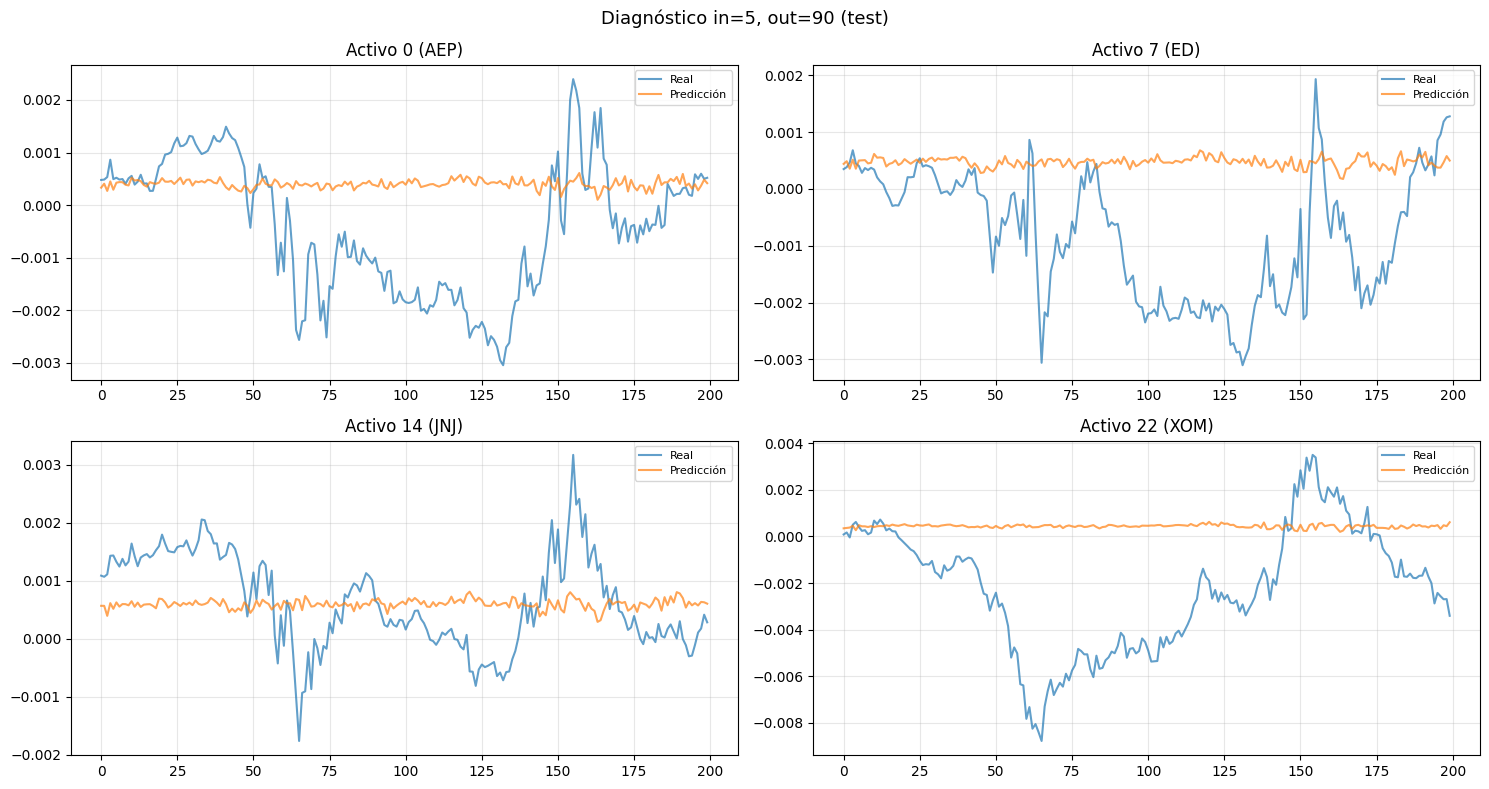

In [232]:
# Compara con el caso fácil: out largo suaviza el target
diagnostico(5, 90, split='test')

=== Diagnóstico in=90, out=1 (split=val) ===

Real:   media=+0.00011  std=0.01745
Pred:   media=+0.00031  std=0.00184
MAE:    0.01164
Var ratio (pred/real): 0.105
Corr (media entre activos):  +0.017
Corr (rango entre activos): [-0.030, +0.070]

⚠ El modelo predice CASI PLANO: la predicción tiene mucha menos varianza que el real.
  Está cayendo hacia la media. Causa típica: target dominado por ruido, modelo se rinde.
⚠ Correlación muy baja: el modelo no captura la dinámica del activo.


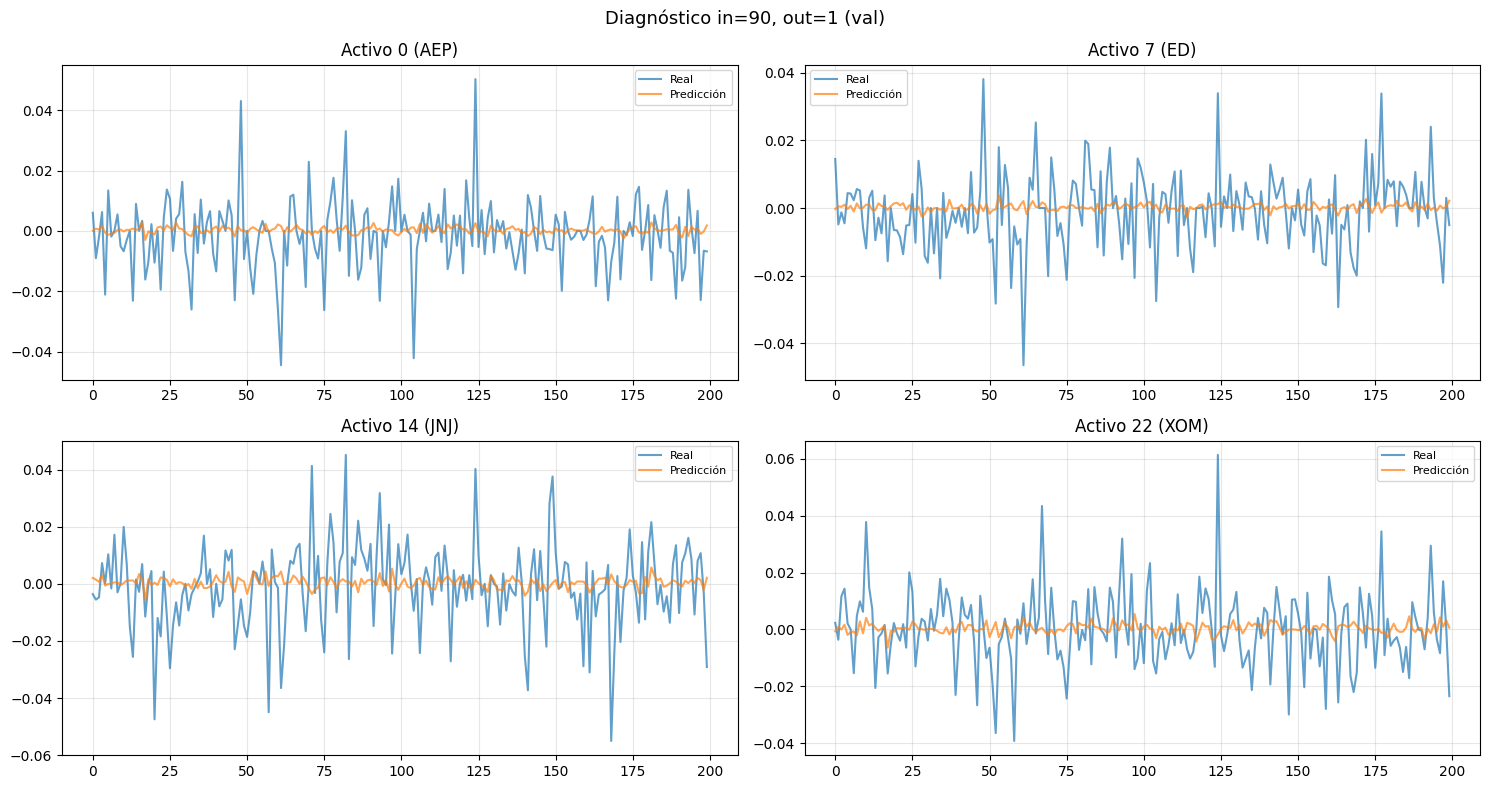

In [233]:
# Misma combinación pero en val (misma distribución que train) para distinguir
# si el problema es shift de distribución o capacidad del modelo
diagnostico(90, 1, split='val')

## Comparativa final: MLP vs Baselines

Se compara el MAE en test de las 16 combinaciones contra dos baselines:

- **Buy & Hold:** estrategia pasiva que predice el retorno medio histórico de cada activo. Representa el mínimo esperado de cualquier modelo activo.
- **Regresión Lineal:** modelo lineal entrenado con las mismas features. Representa el límite de lo que se puede conseguir sin no-linealidades.

En la tabla, el mejor resultado por combinación aparece en **negrita**. Las columnas "MLP vs Lineal" y "MLP vs B&H" muestran la mejora relativa del MLP en test.

=== Tabla comparativa MAE test ===

 in  out Buy & Hold  Lineal         MLP MLP vs Lineal MLP vs B&H
  5    1    0.01785 0.01244 **0.01231**         +1.0%     +31.0%
  5    5    0.01370 0.00565 **0.00560**         +0.9%     +59.1%
  5   30    0.01253 0.00234 **0.00233**         +0.5%     +81.4%
  5   90    0.01223 0.00128 **0.00127**         +0.7%     +89.6%
 10    1    0.01785 0.01261 **0.01235**         +2.1%     +30.8%
 10    5    0.01371 0.00571 **0.00561**         +1.7%     +59.0%
 10   30    0.01253 0.00236 **0.00233**         +1.2%     +81.4%
 10   90    0.01223 0.00129 **0.00127**         +1.3%     +89.6%
 30    1    0.01786 0.01297 **0.01234**         +4.9%     +30.9%
 30    5    0.01372 0.00592 **0.00561**         +5.1%     +59.1%
 30   30    0.01254 0.00244 **0.00233**         +4.4%     +81.4%
 30   90    0.01223 0.00135 **0.00127**         +5.7%     +89.6%
 90    1    0.01788 0.01418 **0.01243**        +12.4%     +30.5%
 90    5    0.01373 0.00638 **0.00574**        +10.1% 

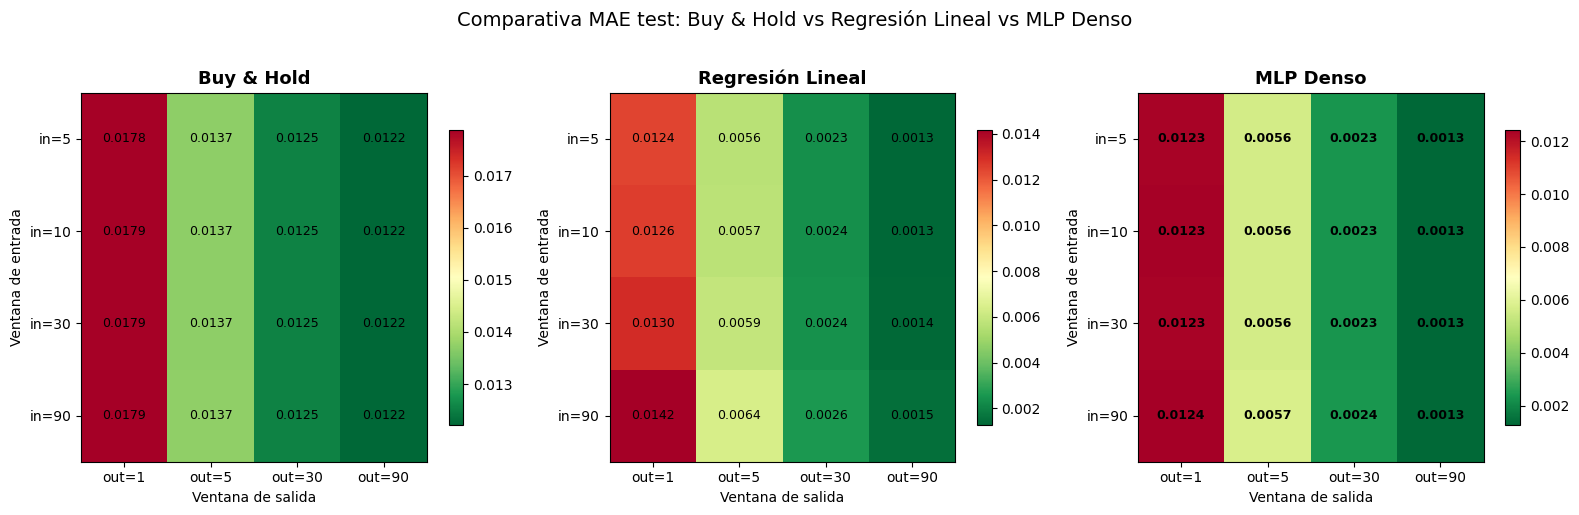


=== ¿Quién gana en test? ===
MLP Denso gana en:        16/16 combinaciones
Regresión Lineal gana en: 0/16 combinaciones
Buy & Hold gana en:       0/16 combinaciones

Mejora media MLP vs Lineal en test: +4.5%


In [234]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Leer CSVs ──────────────────────────────────────────────────────────────
df_mlp    = pd.read_csv('../results/mlp_resultados.csv')
df_lineal = pd.read_csv('../results/regresion_lineal_resultados.csv')
df_bh     = pd.read_csv('../results/buy_and_hold_resultados.csv')

input_windows  = [5, 10, 30, 90]
output_windows = [1, 5, 30, 90]

def get_mae(df, in_w, out_w, col='mae_test'):
    return df[(df['input_window']==in_w) & (df['output_window']==out_w)][col].values[0]

# ── Tabla comparativa ──────────────────────────────────────────────────────
rows = []
for in_w in input_windows:
    for out_w in output_windows:
        mlp = get_mae(df_mlp,    in_w, out_w)
        lin = get_mae(df_lineal, in_w, out_w)
        bh  = get_mae(df_bh,     in_w, out_w)
        mejor = min(mlp, lin, bh)
        def fmt(v):
            return f"**{v:.5f}**" if v == mejor else f"{v:.5f}"
        rows.append({
            'in': in_w, 'out': out_w,
            'Buy & Hold': fmt(bh),
            'Lineal':     fmt(lin),
            'MLP':        fmt(mlp),
            'MLP vs Lineal': f"{(lin-mlp)/lin*100:+.1f}%",
            'MLP vs B&H':    f"{(bh-mlp)/bh*100:+.1f}%",
        })

df_comp = pd.DataFrame(rows)
print("=== Tabla comparativa MAE test ===\n")
print(df_comp.to_string(index=False))

# ── Heatmap ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

modelos = [
    ('Buy & Hold',        df_bh),
    ('Regresión Lineal',  df_lineal),
    ('MLP Denso',         df_mlp),
]

for ax, (nombre, df) in zip(axes, modelos):
    matriz = np.array([[get_mae(df, in_w, out_w)
                        for out_w in output_windows]
                       for in_w in input_windows])

    im = ax.imshow(matriz, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(len(output_windows)))
    ax.set_yticks(range(len(input_windows)))
    ax.set_xticklabels([f'out={w}' for w in output_windows])
    ax.set_yticklabels([f'in={w}' for w in input_windows])
    ax.set_title(nombre, fontsize=13, fontweight='bold')
    ax.set_xlabel('Ventana de salida')
    ax.set_ylabel('Ventana de entrada')

    for i, in_w in enumerate(input_windows):
        for j, out_w in enumerate(output_windows):
            val = matriz[i, j]
            es_mejor = val == min(
                get_mae(df_mlp,    in_w, out_w),
                get_mae(df_lineal, in_w, out_w),
                get_mae(df_bh,     in_w, out_w)
            )
            ax.text(j, i, f'{val:.4f}',
                    ha='center', va='center', fontsize=9,
                    fontweight='bold' if es_mejor else 'normal')

    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Comparativa MAE test: Buy & Hold vs Regresión Lineal vs MLP Denso',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/mlp_v2_heatmap_comparativo.png',
            dpi=100, bbox_inches='tight')
plt.show()

# ── Resumen numérico ───────────────────────────────────────────────────────
n_mlp = n_lin = n_bh = 0
mejoras = []
for in_w in input_windows:
    for out_w in output_windows:
        mlp = get_mae(df_mlp,    in_w, out_w)
        lin = get_mae(df_lineal, in_w, out_w)
        bh  = get_mae(df_bh,     in_w, out_w)
        mejor = min(mlp, lin, bh)
        if mlp == mejor: n_mlp += 1
        elif lin == mejor: n_lin += 1
        else: n_bh += 1
        mejoras.append((lin - mlp) / lin * 100)

print(f"\n=== ¿Quién gana en test? ===")
print(f"MLP Denso gana en:        {n_mlp}/16 combinaciones")
print(f"Regresión Lineal gana en: {n_lin}/16 combinaciones")
print(f"Buy & Hold gana en:       {n_bh}/16 combinaciones")
print(f"\nMejora media MLP vs Lineal en test: {np.mean(mejoras):+.1f}%")

## Conclusiones

### Resultados

El MLP Denso supera a la Regresión Lineal en las **16/16 combinaciones** en test, con una mejora media del **+4.3%**. Frente a Buy & Hold, la mejora es del **+30% al +89%** según la combinación.

La mejora vs Lineal es especialmente pronunciada en ventanas largas:
- **in=90/out=1:** +12.3% sobre la lineal. La no-linealidad del MLP captura interacciones entre activos que la lineal no puede modelar cuando el input es rico en información.
- **in=90/out=30 y out=90:** +8% sobre la lineal. Con target suavizado y mucha historia disponible, el MLP extrae tendencias de momentum que la lineal aproxima peor.

### Limitaciones del MLP denso

**Dilema con ventanas largas:** el MLP enfrenta un trade-off estructural en in=90. Con Flatten (2070 features) sobreajusta desde el primer epoch. Con GlobalAveragePooling pierde toda información temporal. AveragePooling1D(pool_size=3) es el compromiso que resuelve este trade-off parcialmente, pero no elimina la limitación fundamental: el MLP no tiene mecanismo para capturar dependencias temporales de largo alcance de forma eficiente.

**Predicción casi plana:** el var ratio pred/real es bajo (0.1-0.3) en todas las combinaciones. El modelo predice una versión suavizada del target real, colapsando hacia la media histórica. Esto es matemáticamente óptimo bajo MAE cuando el target está dominado por ruido, pero implica que el modelo no captura la dinámica temporal real de los activos.

**Gap val-test:** el gap entre MAE val y MAE test es inherente al split cronológico. Val pertenece al periodo ~1962-2012 (misma distribución que train); test pertenece al periodo ~2012-2026 (régimen diferente del mercado). Este shift de distribución afecta a todos los modelos por igual y no se resuelve con la arquitectura.

### Motivación para los siguientes modelos

Las limitaciones identificadas motivan directamente el uso de arquitecturas más sofisticadas:

- **RNN / LSTM / GRU:** procesan la secuencia temporal de forma explícita con memoria de estado. Pueden capturar dependencias temporales de largo alcance sin el dilema Flatten vs Pooling.
- **CNN 1D:** extraen patrones locales en la secuencia temporal con campos receptivos controlados. Reducen la dimensión efectiva sin perder estructura temporal.
- **Modelos mixtos:** combinan convoluciones para extracción de features locales con capas recurrentes para dependencias globales.

El MLP denso establece un baseline sólido que los modelos siguientes deberán superar para justificar su mayor complejidad.